# Serial recall: kapacitet, fejl og parrede sammenligninger
Kør **Run All** fra denne mappe eller projektmappen. Kræver Python, pandas, matplotlib og scipy.
Notebooken læser de tre originale JSON-filer direkte og ændrer dem ikke.

Output: kapacitetsgraf og fejlgraf (PNG/SVG), to LaTeX-tabeller samt CSV-filer med
forsøg, deltagerforskelle og opsummeringer. Figurer og tabeller er på engelsk.

## Analysevalg
- Kun fuldførte, ikke-test sessioner med samtykke i `final-v2.1-draft`.
- Kvalitetsflag anvendes separat per sektion. Manglende/udelukkede observationer er ikke nul.
- Accuracy er den gemte `positional_accuracy` (korrekt bogstav på korrekt position).
- Kapacitet: baseline ved 6–9 bogstaver og den parrede forskel baseline 9 minus baseline 6.
- Fejl: de fem gemte optællinger bruges direkte, uden ny klassifikation. Fejloversigten omfatter kun baselineforsøgene (6–9 bogstaver).
- Chunking: grouped minus baseline ved 9 bogstaver.
- Suppression og tapping: test minus samme persons baseline ved samme længde.
- Intervaller beregnes på tværs af deltagere med t-fordelingen, ikke på tværs af enkeltbogstaver.
- Positive forskelle betyder højere accuracy i den førstnævnte betingelse.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import t as student_t
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DATA_DIR = Path.cwd()
if not (DATA_DIR / "supabase_export_anonymized.json").exists():
    DATA_DIR = DATA_DIR / "human memory experiment"
def read_json(name):
    return json.loads((DATA_DIR / name).read_text(encoding="utf-8"))
data = read_json("supabase_export_anonymized.json")
quality = read_json("quality_assessment.json")
manifest = read_json("export_manifest.json")
PROTOCOL = "final-v2.1-draft"
assert manifest["protocol_version"] == quality["protocol_version"] == PROTOCOL
assert len(data["sessions"]) == manifest["sessions"]
assert len(data["trials"]) == manifest["trials"]
q_by_id = {q["session_id"]: q for q in quality["sessions"]}
assert len(q_by_id) == len(quality["sessions"])
assert len({s["id"] for s in data["sessions"]}) == len(data["sessions"])
assert len({r["id"] for r in data["trials"]}) == len(data["trials"])
assert {s["id"] for s in data["sessions"]} == set(q_by_id)
assert all(r["session_id"] in q_by_id for r in data["trials"])
participants = [s for s in data["sessions"] if s["protocol_version"] == PROTOCOL
                and s["status"] == "completed" and s["consent_given"]
                and not q_by_id[s["id"]]["is_test_session"]]
assert len({s["participant_code"] for s in participants}) == len(participants)

def mean_ci(values):
    values = pd.Series(values).dropna().astype(float)
    n = len(values)
    mean = values.mean()
    sd = values.std(ddof=1)
    half = student_t.ppf(0.975, n-1) * sd / np.sqrt(n) if n >= 2 else np.nan
    return dict(n=n, mean=mean, sd=sd, ci_low=mean-half, ci_high=mean+half)

print(f"Snapshot: {manifest['exported_at']}; {len(participants)} completed real participants.")

Snapshot: 2026-09-22T18:08:26.013023+00:00; 17 completed real participants.


## 1. Indlæs brugbare serial recall-forsøg
Fejloptællingerne i `score` er allerede kontrolleret af projektgruppen og bevares som gemt.
Vi kontrollerer struktur, gyldige værdier og sammenhængen mellem antal positionstræffere og accuracy.

In [2]:
ERRORS = ["omissions", "intrusions", "substitutions", "repetitions", "transpositions"]
SECTION = {**{f"baseline_{n}": "serial_baseline" for n in range(6,10)},
           "articulatory_suppression": "articulatory_suppression",
           "finger_tapping": "finger_tapping", "grouped": "chunking"}
EXPECTED_LENGTH = {**{f"baseline_{n}": n for n in range(6,10)}, "grouped": 9}
rows = []
for s in participants:
    q = q_by_id[s["id"]]
    assert q["participant_id"] == s["participant_code"]
    trials = [r for r in data["trials"] if r["session_id"] == s["id"]
              and r["experiment_type"] == "serial_recall" and r["completed"]]
    assert len({r["condition"] for r in trials}) == len(trials)
    conditions = {r["condition"] for r in trials}
    for condition, sec in SECTION.items():
        if q["usable"][sec]:
            assert condition in conditions, (s["participant_code"], condition)
    for r in trials:
        assert r["condition"] in SECTION
        if not q["usable"][SECTION[r["condition"]]]:
            continue
        score = r["score"]
        length = score["presented_length"]
        assert length == len(r["presented_sequence"])
        assert length in range(6,10)
        if r["condition"] in EXPECTED_LENGTH:
            assert length == EXPECTED_LENGTH[r["condition"]]
        assert 0 <= score["positional_accuracy"] <= 1
        assert np.isclose(score["positional_accuracy"], score["positional_matches"] / length)
        for error in ERRORS:
            assert isinstance(score[error], int) and score[error] >= 0
        rows.append(dict(participant_id=s["participant_code"], condition=r["condition"],
                         length=length, accuracy=score["positional_accuracy"],
                         **{e: score[e] for e in ERRORS}))
trials_df = pd.DataFrame(rows)
trials_df.to_csv(DATA_DIR / "serial_trials.csv", index=False)
print(trials_df.groupby("condition").size().to_string())

condition
articulatory_suppression    16
baseline_6                  17
baseline_7                  17
baseline_8                  17
baseline_9                  17
finger_tapping              15
grouped                     17


## 2. Kapacitet: præstation ved 6–9 bogstaver
Hvert punkt er deltagernes gennemsnit ved den givne længde. Fejllinjerne er punktvise
95 % t-intervaller. De er ikke korrigeret for flere sammenligninger.
T-intervaller er ikke afklippet til 0–100 %, hvis beregningen skulle give en grænse udenfor.
Kurven viser præstation ved øget belastning, ikke et præcist memory-span-estimat.

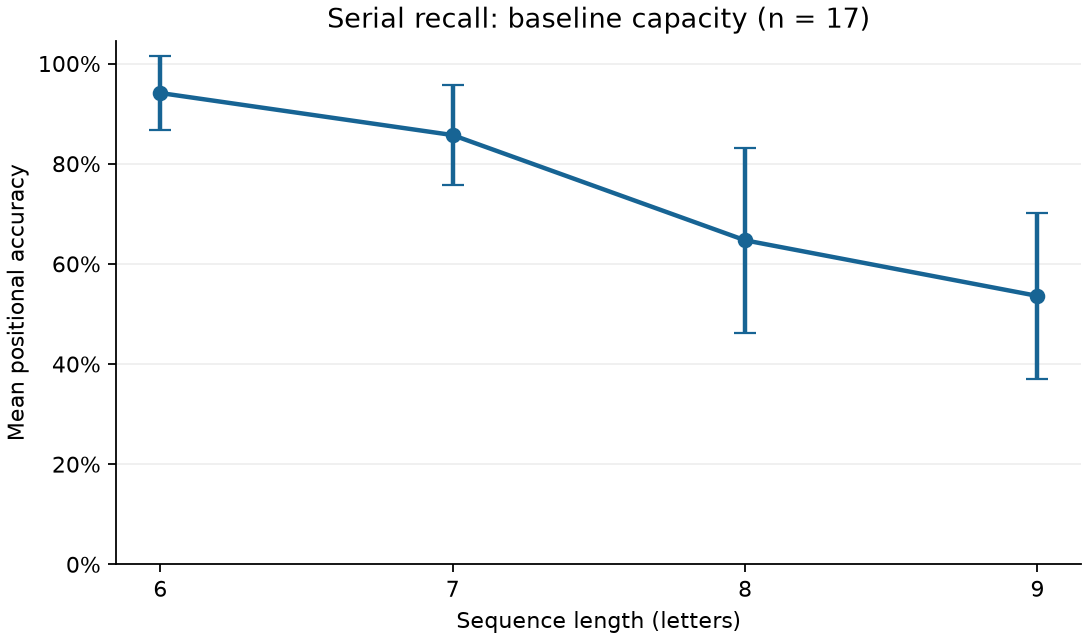

,length,n,mean,sd,ci_low,ci_high
0,6,17,0.941176,0.143628,0.867330,1.015023
1,7,17,0.857143,0.195615,0.756567,0.957719
2,8,17,0.647059,0.359675,0.462131,0.831986
3,9,17,0.535948,0.322115,0.370331,0.701564


In [3]:
baseline = trials_df[trials_df["condition"].str.startswith("baseline_")].copy()
capacity = pd.DataFrame([dict(length=length, **mean_ci(g["accuracy"]))
                         for length, g in baseline.groupby("length")])
capacity.to_csv(DATA_DIR / "serial_capacity_summary.csv", index=False)
fig, ax = plt.subplots(figsize=(6.8, 4), layout="constrained")
ax.errorbar(capacity["length"], capacity["mean"],
            yerr=[capacity["mean"]-capacity["ci_low"], capacity["ci_high"]-capacity["mean"]],
            fmt="o-", color="#176494", capsize=5, linewidth=2)
ax.set(xlabel="Sequence length (letters)", ylabel="Mean positional accuracy",
       title=f"Serial recall: baseline capacity (n = {baseline.participant_id.nunique()})",
       xticks=[6,7,8,9])
ax.set_ylim(min(0, capacity.ci_low.min()-0.03), max(1.03, capacity.ci_high.max()+0.03))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
fig.savefig(DATA_DIR / "serial_capacity.png", dpi=200)
fig.savefig(DATA_DIR / "serial_capacity.svg")
plt.show()
display(capacity)

## 3. Parrede forskelle
Hver deltager vægter én gang i hver sammenligning. En forskel beregnes kun, hvis begge
målinger er brugbare. Baseline matches på længden i suppression/tapping.
Gennemsnit og intervaller i tabellerne ganges med 100 og angives i procentpoint.

In [4]:
accuracy = trials_df.pivot(index="participant_id", columns="condition", values="accuracy")
lengths = trials_df.pivot(index="participant_id", columns="condition", values="length")
paired = pd.DataFrame(index=sorted(s["participant_code"] for s in participants))
paired.index.name = "participant_id"
for condition in SECTION:
    paired[f"{condition}_accuracy"] = accuracy.reindex(index=paired.index, columns=[condition])[condition]
for task in ["articulatory_suppression", "finger_tapping"]:
    paired[f"{task}_length"] = lengths.reindex(index=paired.index, columns=[task])[task]
    matched = []
    for pid, length in paired[f"{task}_length"].items():
        matched.append(paired.loc[pid, f"baseline_{int(length)}_accuracy"] if pd.notna(length) else np.nan)
    paired[f"{task}_matched_baseline_accuracy"] = matched
    paired[f"{task}_diff"] = paired[f"{task}_accuracy"] - paired[f"{task}_matched_baseline_accuracy"]
paired["chunking_diff"] = paired["grouped_accuracy"] - paired["baseline_9_accuracy"]
paired["capacity_9_minus_6_diff"] = paired["baseline_9_accuracy"] - paired["baseline_6_accuracy"]
paired.to_csv(DATA_DIR / "serial_participant_differences.csv", na_rep="")
COMPARISONS = {"chunking_diff": "Chunking $-$ baseline (9 letters)",
               "articulatory_suppression_diff": "Suppression $-$ matched baseline",
               "finger_tapping_diff": "Tapping $-$ matched baseline"}
comparison_summary = pd.DataFrame([dict(effect=col, **mean_ci(paired[col])) for col in COMPARISONS])
comparison_summary.to_csv(DATA_DIR / "serial_comparison_summary.csv", index=False)
capacity_difference = mean_ci(paired["capacity_9_minus_6_diff"])
print("Baseline 9 minus baseline 6:")
print(f"n={capacity_difference['n']}, mean={100*capacity_difference['mean']:.1f} pp, "
      f"95% CI [{100*capacity_difference['ci_low']:.1f}, {100*capacity_difference['ci_high']:.1f}] pp")
display(comparison_summary)

Baseline 9 minus baseline 6:
n=17, mean=-40.5 pp, 95% CI [-59.3, -21.7] pp


,effect,n,mean,sd,ci_low,ci_high
0,chunking_diff,17,0.411765,0.301142,0.256932,0.566597
1,articulatory_suppression_diff,16,-0.389881,0.359082,-0.581222,-0.198540
2,finger_tapping_diff,15,-0.360317,0.440303,-0.604149,-0.116486


## 4. Fejloversigt fra de gemte optællinger
Vi summerer hver fejltype over baselineforsøgene ved 6, 7, 8 og 9 bogstaver for hver deltager.
Tabellen viser totalen, gennemsnit per deltager over de fire forsøg og antal fejl per 100
præsenterede bogstaver. Den sidste størrelse er **ikke andelen af alle fejl**.
Kategorier kan overlappe; de skal ikke lægges sammen som en procentfordeling.
Alle baseline-deltagere skal have alle fire længder, så eksponeringen er den samme.

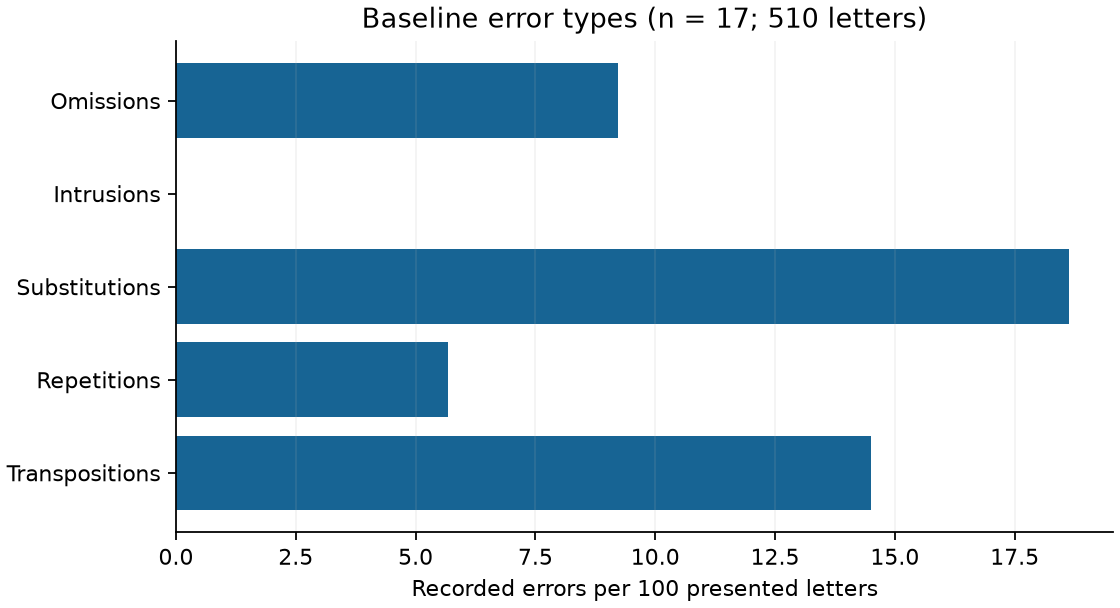

,error_type,total,mean_per_participant,per_100_letters
0,omissions,47,2.764706,9.215686
1,intrusions,0,0.000000,0.000000
2,substitutions,95,5.588235,18.627451
3,repetitions,29,1.705882,5.686275
4,transpositions,74,4.352941,14.509804


In [5]:
assert baseline.groupby("participant_id").size().eq(4).all()
assert baseline.groupby("participant_id")["length"].sum().eq(30).all()
errors_by_person = baseline.groupby("participant_id")[ERRORS].sum()
errors_by_person.to_csv(DATA_DIR / "serial_errors_by_participant.csv")
total_letters = int(baseline["length"].sum())
error_summary = pd.DataFrame([dict(error_type=e, total=int(errors_by_person[e].sum()),
                                   mean_per_participant=errors_by_person[e].mean(),
                                   per_100_letters=100*errors_by_person[e].sum()/total_letters)
                              for e in ERRORS])
error_summary.to_csv(DATA_DIR / "serial_error_summary.csv", index=False)
fig, ax = plt.subplots(figsize=(7, 3.8), layout="constrained")
ax.barh(error_summary.error_type.str.title(), error_summary.per_100_letters, color="#176494")
ax.invert_yaxis()
ax.set(xlabel="Recorded errors per 100 presented letters",
       title=f"Baseline error types (n = {len(errors_by_person)}; {total_letters} letters)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.15)
fig.savefig(DATA_DIR / "serial_error_types.png", dpi=200)
fig.savefig(DATA_DIR / "serial_error_types.svg")
plt.show()
display(error_summary)

## 5. LaTeX-tabeller
Brug `\usepackage{booktabs}` i rapportens præambel. Koden gemmes også i to `.tex`-filer.
Konfidensintervallerne er ukorrigerede. Et interval, der indeholder nul, dokumenterer ikke,
at effekten er fraværende. De adaptive længder og den faste forsøgsrækkefølge begrænser
fortolkningen af sammenligningerne. Der udføres ingen analyse af lydlig lighed her.

In [6]:
error_lines = []
for row in error_summary.itertuples():
    error_lines.append(f"        {row.error_type.title()} & {row.total} & {row.mean_per_participant:.2f} & {row.per_100_letters:.2f}" + r" \\")
error_latex = r"""\begin{table}[htbp]
    \centering
    \small
    \begin{tabular}{lrrr}
        \toprule
        Error type & Total & Mean per participant & Per 100 letters \\
        \midrule
""" + "\n".join(error_lines) + r"""
        \bottomrule
    \end{tabular}
    \caption{Recorded error counts across the four serial-recall
    baseline trials (6--9 letters; $n=NCOUNT$; LETTERCOUNT presented letters).
    Participant means refer to totals across all four trials.
    Error categories may overlap.}
    \label{tab:serial-errors}
\end{table}
"""
error_latex = error_latex.replace("NCOUNT", str(len(errors_by_person))).replace("LETTERCOUNT", str(total_letters))
comparison_lines = []
for row in comparison_summary.itertuples():
    comparison_lines.append(f"        {COMPARISONS[row.effect]} & {row.n} & ${100*row.mean:.1f}$ & $[{100*row.ci_low:.1f},\\;{100*row.ci_high:.1f}]$" + r" \\")
comparison_latex = r"""\begin{table}[htbp]
    \centering
    \small
    \begin{tabular}{lrrr}
        \toprule
        Comparison & $n$ & Mean (pp) & 95\% CI (pp) \\
        \midrule
""" + "\n".join(comparison_lines) + r"""
        \bottomrule
    \end{tabular}
    \caption{Mean within-participant differences in positional
    accuracy, expressed in percentage points (pp), with two-sided
    95\% paired t-confidence intervals. Differences are test minus
    baseline at the same sequence length. Intervals are not adjusted
    for multiple comparisons.}
    \label{tab:serial-comparisons}
\end{table}
"""
(DATA_DIR / "serial_errors_table.tex").write_text(error_latex, encoding="utf-8")
(DATA_DIR / "serial_comparisons_table.tex").write_text(comparison_latex, encoding="utf-8")
print(error_latex)
print(comparison_latex)

\begin{table}[htbp]
    \centering
    \small
    \begin{tabular}{lrrr}
        \toprule
        Error type & Total & Mean per participant & Per 100 letters \\
        \midrule
        Omissions & 47 & 2.76 & 9.22 \\
        Intrusions & 0 & 0.00 & 0.00 \\
        Substitutions & 95 & 5.59 & 18.63 \\
        Repetitions & 29 & 1.71 & 5.69 \\
        Transpositions & 74 & 4.35 & 14.51 \\
        \bottomrule
    \end{tabular}
    \caption{Recorded error counts across the four serial-recall
    baseline trials (6--9 letters; $n=17$; 510 presented letters).
    Participant means refer to totals across all four trials.
    Error categories may overlap.}
    \label{tab:serial-errors}
\end{table}

\begin{table}[htbp]
    \centering
    \small
    \begin{tabular}{lrrr}
        \toprule
        Comparison & $n$ & Mean (pp) & 95\% CI (pp) \\
        \midrule
        Chunking $-$ baseline (9 letters) & 17 & $41.2$ & $[25.7,\;56.7]$ \\
        Suppression $-$ matched baseline & 16 & $-39.0$ & $[-5